First we import the library, forcing reload from local version (not pip install). 

In [1]:
import os
import sys
import importlib
import matplotlib.pyplot as plt


# Get the absolute path to the directory containing the local module
stlrom_path = os.path.abspath('../build')
print(stlrom_path)

# Insert the local module path at the beginning of sys.path
sys.path.insert(0, stlrom_path)

import stlrom

# Reload the module to ensure it is loaded from the new path
importlib.reload(stlrom)

import stlrom as sr
import numpy as np

print(sr.Signal.get_interpol())


/home/dayekhh/Documents/git-repos/stlrom2/build
LINEAR


# Signals


## Function


## Test signals

### Basic test signals

### Longer signals

# Testing monitors


In [ ]:
stl_parser = stlrom.STLDriver()
stl_parser.parse_string("""signal x, y       # declaring signals named 'x' and 'y'
param p=0.2, tau=5  # declaring parameters named 'p' and 'q'
# Let's add some formulas
mu_x := x[t] > p
mu_x_times := x[t] * tau > p
mu_or := mu_x or mu_x_times
mu_plus_times = (x[t] * tau) + x[t] > p
phi_x := ev_[0, tau] ( mu_x )
mu_y := y[t] < p 
mu := mu_x and mu_y 
phi_y := y[t]>p => ev_[0, tau] (y[t]<p)
""")


True

In [3]:
# Helper, to add data to a monitor
def add_signals(mon,times, sig_x, sig_y):
    for i in range(0, len(times)):
        mon.add_sample([times[i],sig_x[i],sig_y[i]])
    return mon


Monitoring phi_x

## Some plots

<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

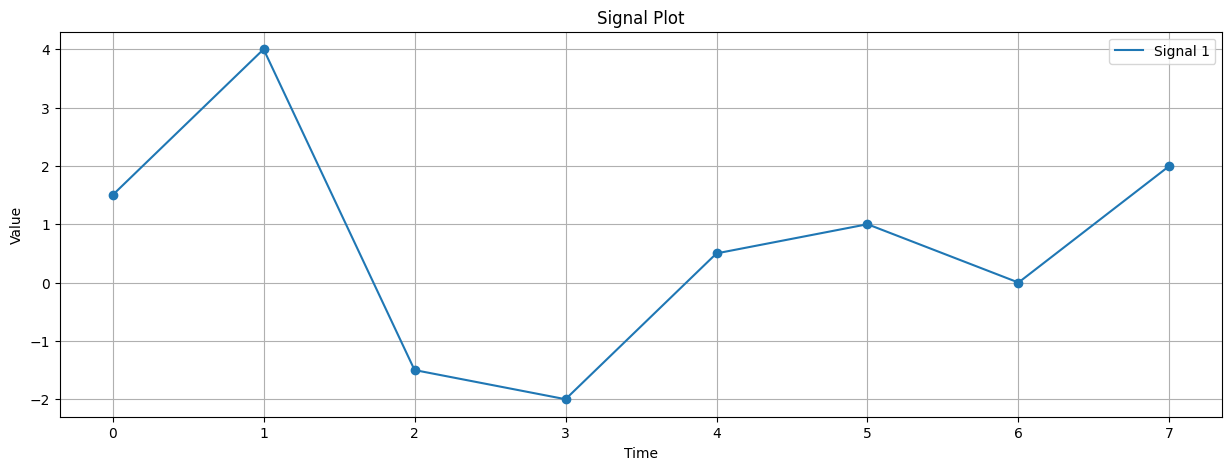

In [4]:

sig_test = sr.Signal()


times = np.array([0, 1, 2, 3, 4, 5, 6, 7])
sig_test_samples = np.array([1.5, 4., -1.5, -2, .5, 1, 0, 2]
)
for t, x in zip(times, sig_test_samples):
    sig_test.append_sample(t, x)

sig_test.plot()


interpol:LINEAR
def = [0, 7)
           0             0  0
           7             0  0

def = [0, 7)
           0             0  0
           7             0  0

def = [0, 7)
           0             0  0
           7             0  0

interpol:LINEAR
def = [0, 7)
           0             0  0
           7             0  0

def = [0, 7)
           0             0  0
           7             0  0

def = [0, 7)
           0             0  0
           7             0  0



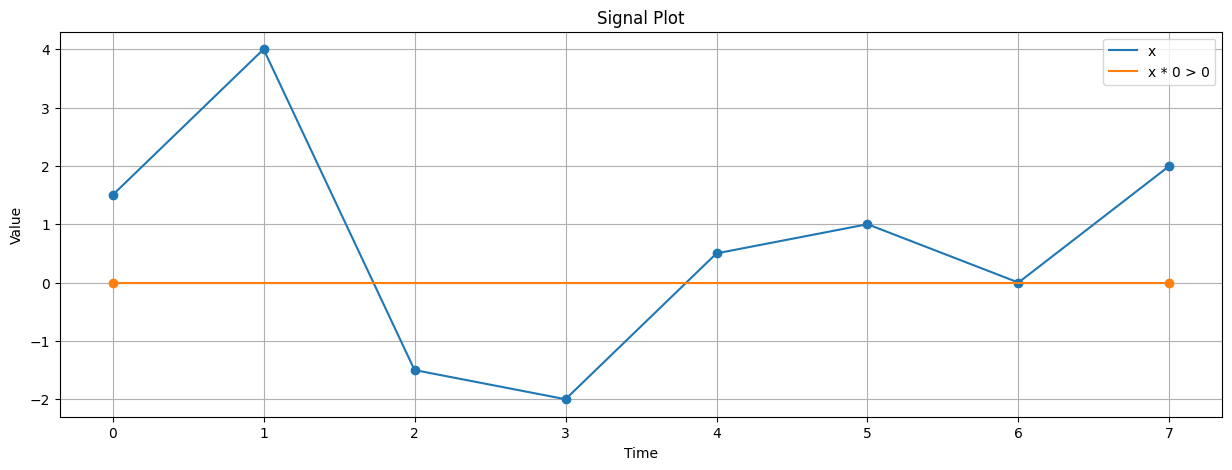

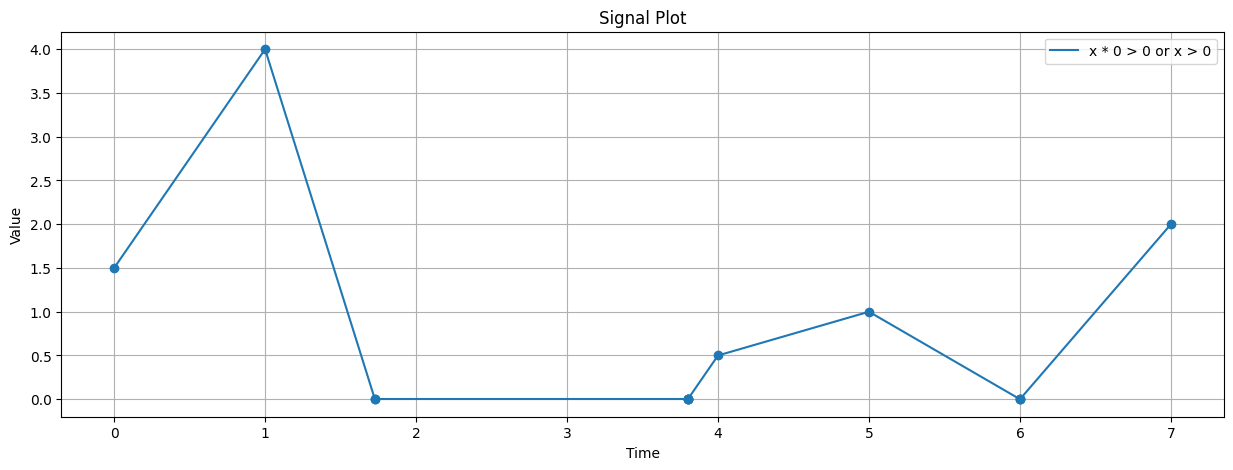

In [5]:
interp = "LINEAR"

sr.Signal.set_Eps(.0000009)
sr.Signal.set_BigM(6)

# mu_x_times is x[t] * tau > p
mu_x_times = stl_parser.get_monitor("mu_x_times")
mu_x_times = add_signals(mu_x_times, times, sig_test_samples, sig_test_samples)
mu_x_times.set_eval_time(times[0], times[-1])
mu_x_times.set_param("p", 0)
mu_x_times.set_param("tau", -0)


# mu_or is x[t] * tau > p
mu_or = stl_parser.get_monitor("mu_or")
mu_or = add_signals(mu_or, times, sig_test_samples, sig_test_samples)
mu_or.set_eval_time(times[0], times[-1])
mu_or.set_param("p", 0)
mu_or.set_param("tau", -0)



fig = sig_test.plot(label="x")



mu_x_times.set_semantics("SPACE")
mu_x_times.set_interpol(interp)
mu_x_times.eval_rob()
z_times = mu_x_times.get_signal()
fig = z_times.plot(label="x * 0 > 0", fig=fig)

mu_or.set_semantics("SPACE")
mu_or.set_interpol(interp)
mu_or.eval_rob()
z_or = mu_or.get_signal()
fig = z_or.plot(label = "x * 0 > 0 or x > 0")